In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [37]:
df = pd.read_csv('/content/drive/MyDrive/file data/insurance.csv')

In [38]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [39]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [40]:
df.shape

(1338, 7)

In [41]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [42]:
df.duplicated().sum()

np.int64(1)

In [43]:
df.drop_duplicates(inplace= True)

In [44]:
df.shape

(1337, 7)

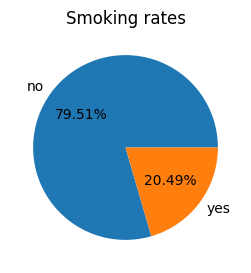

In [45]:
plt.figure(figsize= [8, 3]);
counts_smoker = df['smoker'].value_counts();
plt.pie(counts_smoker, labels= counts_smoker.index, autopct= "%.2f%%");
plt.title('Smoking rates');

Insight: Around 79.51% of the individuals in the dataset are non-smokers, while smokers represent a minority of only 20.49%

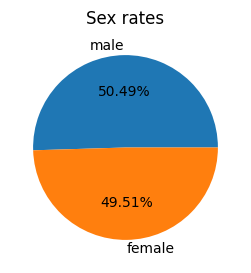

In [46]:
plt.figure(figsize= [8, 3]);
counts_sex = df['sex'].value_counts();
plt.pie(counts_sex, labels= counts_sex.index, autopct= "%.2f%%");
plt.title("Sex rates");

Insight: The dataset shows an almost perfectly balanced gender distribution, with males representing 50.49% and females representing 49.51%.

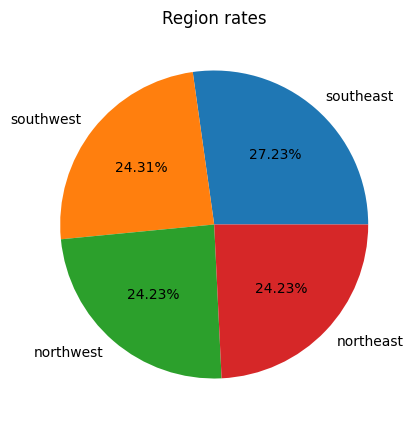

In [75]:
plt.figure(figsize= [10, 5]);
counts_region = df['region'].value_counts();
plt.pie(counts_region, labels= counts_region.index, autopct= "%.2f%%");
plt.title("Region rates");

Insight: The dataset is evenly distributed across the four regions at roughly 24% each, with a slightly higher representation in the southeast region (27.23%).

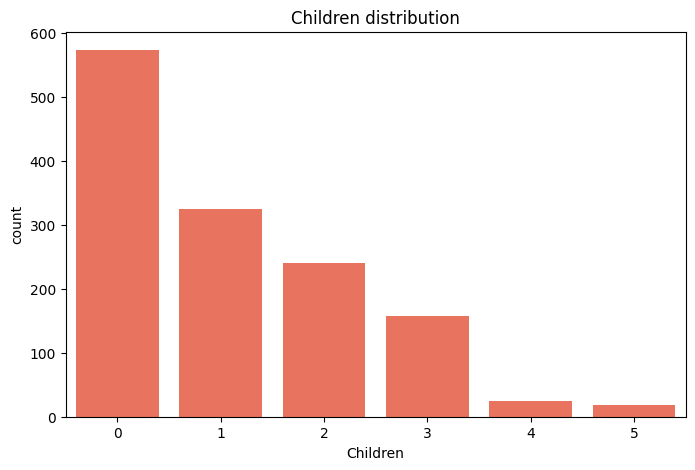

In [69]:
plt.figure(figsize= [8,5]);
sns.countplot(x = df['children'], color="tomato");
plt.title("Children distribution");
plt.xlabel("Children");

Insight: Most individuals in the dataset have 0 children (over 570 people), with the count steadily decreasing as the number of children increases up to 5.

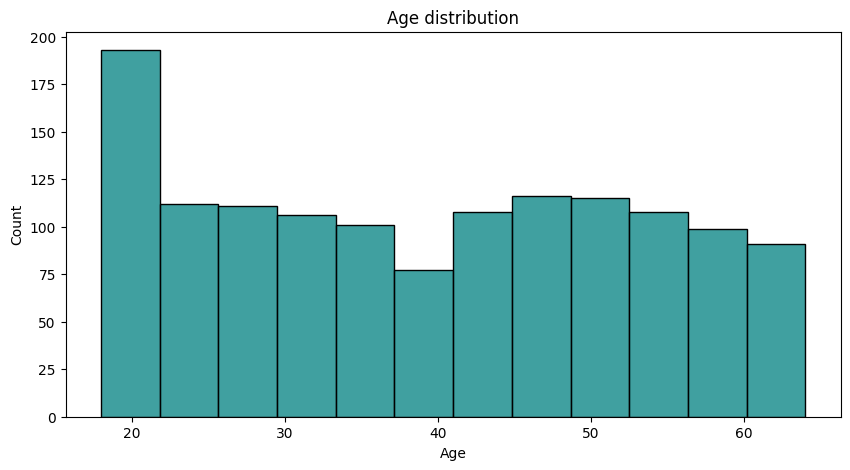

In [47]:
plt.figure(figsize= [10,5]);
sns.histplot(df['age'], color="teal");
plt.title("Age distribution");
plt.xlabel("Age");

Insight: The age distribution is relatively uniform across most age groups, with a distinct peak in the 18–19 demographic (nearly 200 individuals).

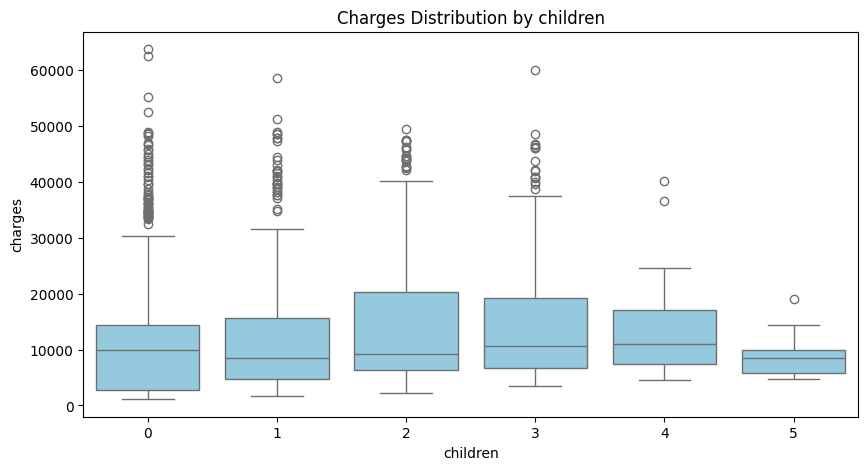

In [58]:
plt.figure(figsize= [10, 5]);
sns.boxplot(x = df['children'], y = df['charges'], color= 'skyblue');
plt.title("Charges Distribution by children");

Insight: The median charges remain consistent across all children categories ($10,000), showing that the number of children has a minimal impact on overall insurance costs.

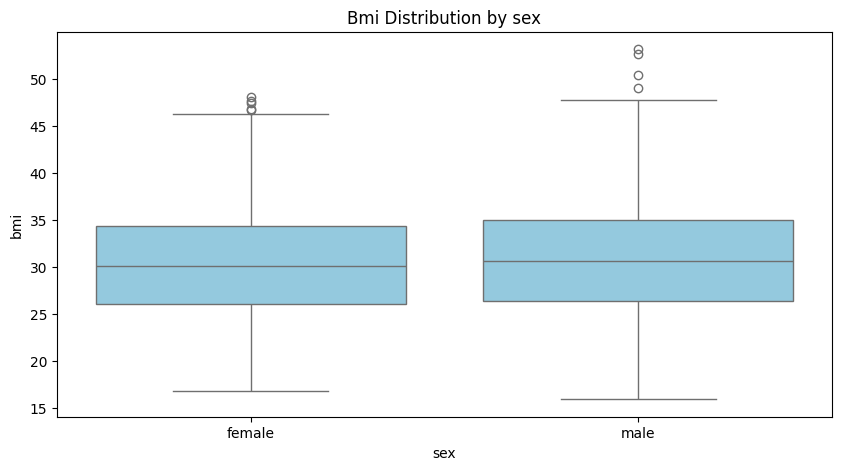

In [59]:
plt.figure(figsize= [10, 5]);
sns.boxplot(x = df['sex'], y = df['bmi'], color= 'skyblue');
plt.title("Bmi Distribution by sex");

Insight: The BMI distribution is nearly identical for both males and females, with a median of around 30, showing that BMI is independent of gender.

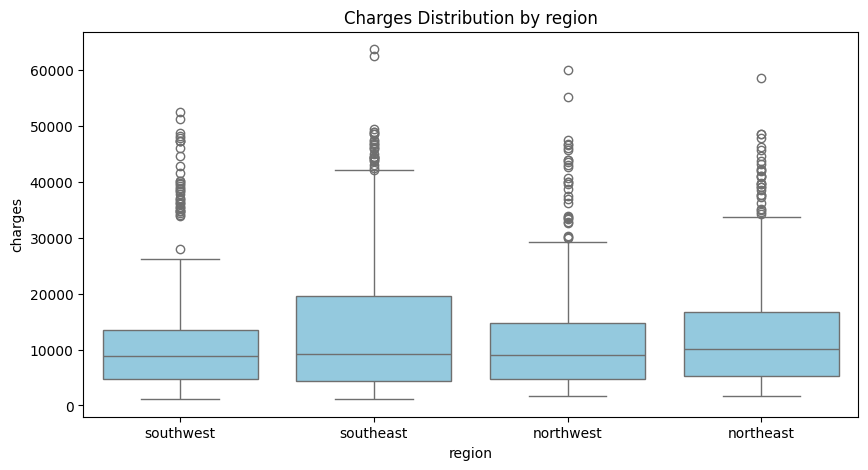

In [86]:
plt.figure(figsize= [10, 5]);
sns.boxplot(x = df['region'], y = df['charges'], color= 'skyblue');
plt.title("Charges Distribution by region");

Insight: Insurance charges are distributed similarly across all four regions with nearly identical median costs ($9,000–$10,000), though the southeast region shows a wider spread and higher extreme cost outliers.

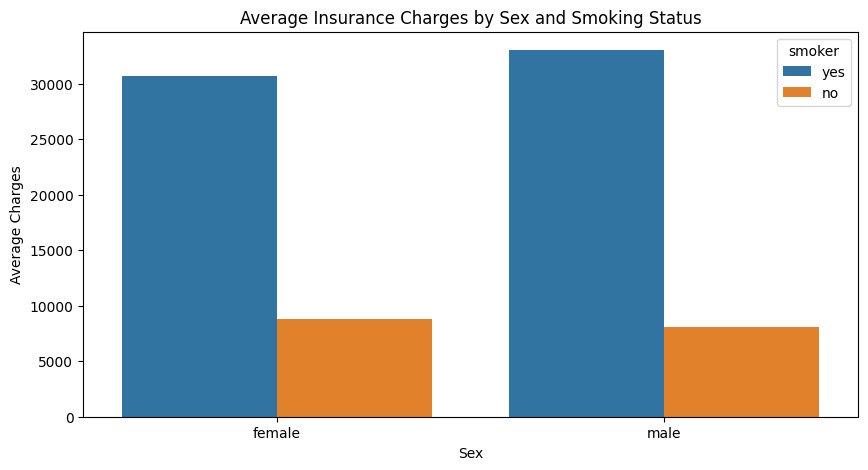

In [80]:
plt.figure(figsize= [10, 5]);
sns.barplot(x = df['sex'], y = df['charges'], hue= df['smoker'], errorbar=None);
plt.title("Average Insurance Charges by Sex and Smoking Status");
plt.xlabel("Sex");
plt.ylabel("Average Charges");

Insight: Smoking status is the key factor driving insurance costs, with smokers averaging over three times higher charges than non-smokers regardless of gender, proving that gender has a negligible impact compared to smoking.

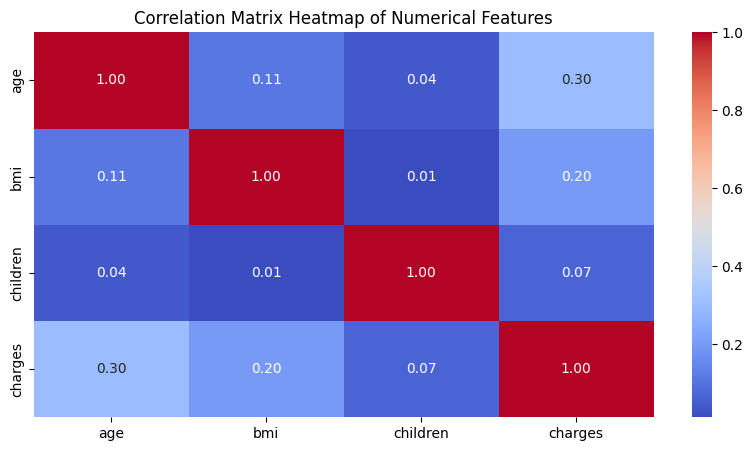

In [84]:
plt.figure(figsize= [10, 5]);
sns.heatmap(df.corr(numeric_only= True), annot= True, cmap= "coolwarm", fmt= ".2f");
plt.title("Correlation Matrix Heatmap of Numerical Features");

The correlation matrix indicates that age has the strongest positive linear relationship with insurance charges ($r = 0.30$), followed by BMI ($r = 0.20$). Meanwhile, children shows virtually no linear correlation with charges ($r = 0.07$), confirming its minimal impact. Additionally, very low correlations among predictors confirm feature independence."

Key Insights:
Smoker Status: Primary cost driver; smokers face exponentially higher charges compared to non-smokers.
Regional Costs: Median charges are consistent across all four regions ($9,000–$10,000), though the southeast region shows higher overall variance and extreme cost outliers.   
Demographics: Gender distribution is balanced (50.5% male, 49.5% female) with negligible impact on charges.
Business Recommendations:
Smoking-based Premium Pricing: Base insurance risk tiers strictly on smoking status rather than geographical region or gender, as region shows minimal variation in baseline costs.
Southeast Region Risk Monitoring: Investigate the underlying causes of high cost outliers in the southeast region (e.g., specific medical provider rates or higher local health risk factors).
Family Bundle Incentives: Since most policyholders have 0 or 1 child (70%), introduce family/dependents promotional plans to encourage larger households to join.
Young Adult Preventive Wellness: Focus smoking cessation programs and wellness initiatives on the 18–25 age group—which forms a significant portion of new clients—to mitigate future claims early on.

In [92]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [93]:
x = df_encoded.drop('charges', axis= 1)
y = df_encoded['charges']

In [95]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [98]:
poly_model = PolynomialFeatures(degree= 2)
x_train_poly = poly_model.fit_transform(x_train)
x_test_poly = poly_model.transform(x_test)

In [99]:
model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred = model.predict(x_test_poly)

In [118]:
mae = mean_absolute_error(y_test, y_pred)
mae

2867.317439475313

In [119]:
mse = mean_squared_error(y_test, y_pred)
mse

21585843.724421978

In [128]:
rmse = np.sqrt(mse)
rmse

np.float64(4646.056793068933)

In [121]:
R_2 = r2_score(y_test, y_pred)
R_2

0.882529897246852

Summary & Key Findings
1. Key Data Insights

Smoking (smoker): Smoking is the single most influential feature driving insurance charges significantly higher.

Age & BMI: Charges increase steadily with age and higher BMI. The interaction between being a smoker and having a high BMI leads to the highest insurance costs.

2. Preprocessing Decisions

One-Hot Encoding: Applied drop_first=True on categorical features to prevent the Dummy Variable Trap and avoid multicollinearity.

Data Structure: Retained data as Pandas DataFrames to preserve feature names for better readability and traceability.

3. Model Evaluation & Conclusion

Polynomial Regression (Degree = 2): Selected because relationships between features and insurance charges are non-linear, involving strong interaction effects between variables.

Performance: Achieved an R² = 0.882529897246852, explaining about 88% of the variance in insurance charges.

Error Metrics: The model achieved MAE = 2867.317439475313 and RMSE = 4646.056793068933, showing high predictive accuracy.

Conclusion: Linear Regression with polynomial terms is a highly suitable model for this dataset.

In [130]:
X_train_L, X_test_L, Y_train_L, Y_test_L = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [131]:
mode_L = LinearRegression()
mode_L

LinearRegression()

In [132]:
mode_L.fit(X_train_L, Y_train_L)
Y_pred_L = mode_L.predict(X_test_L)

In [133]:
mae_L = mean_absolute_error(Y_test_L, Y_pred_L)
mae_L

4177.045561036319

In [134]:
mse_L = mean_squared_error(Y_test_L, Y_pred_L)
mse_L

35478020.67523561

In [137]:
rmse_L = np.sqrt(mse_L)
rmse_L

np.float64(5956.342894363588)

In [136]:
R_2_L = r2_score(Y_test_L, Y_pred_L)
R_2_L

0.8069287081198011

Insight: Model Comparison
The standard Linear Regression model shows higher error metrics ($\text{MAE} \approx 4,177$ and $\text{RMSE} \approx 5,956$) and a lower $R^2$ score ($80.7\%$) compared to Polynomial Regression ($\text{MAE} \approx 2,867$ and $R^2 \approx 88.3\%$). This confirms that the dataset contains non-linear relationships, making Polynomial Regression the better-fitting model.